In [5]:
import numpy as np
# version: numpy 2.3.4
import matplotlib.pyplot as plt
# version: matplotlib 3.9.3

In [6]:
'''
Time domain noise for QRNG
'''
P_LO = np.array([0.00254, 0.00562, 0.01211, 0.07211, 0.3, 0.546, 0.787, 1.035, 1.27,
                 1.51, 1.742, 1.98, 2.202, 2.442, 2.67, 2.89])

collect = np.zeros((17, 375, 512), dtype=np.int16)
collect[0] = np.loadtxt(f'1.23/ele_noise.csv', dtype=np.int16, delimiter=',')

N_e_t = np.full_like(P_LO, collect[0].var())
N_m_t = np.full_like(P_LO, np.nan)

for i in range(1, 17, 1):
    collect[i] = np.loadtxt(fname=f'1.23/{i+2}ma.csv', dtype=np.int16, delimiter=',')
    N_m_t[i-1] = collect[i].var()

N_q_t = N_m_t - N_e_t
QCNR_t = N_q_t / N_e_t
QCNR_t_dB = 10 * np.log10(QCNR_t)

print('ele noise:', N_e_t[0], sep='\n', end='\n\n')
print('measured noise:', N_m_t, sep='\n', end='\n\n')
print('quantum noise:', N_q_t, sep='\n', end='\n\n')
print('QCNR:', QCNR_t, sep='\n', end='\n\n')
print('QCNR(in dB):', QCNR_t_dB, sep='\n', end='\n\n')

ele noise:
2.760559040690104

measured noise:
[ 2.78925019  2.89284241  2.88321852  3.01112749  3.70688246  4.3050462
  5.00975951  5.68020179  6.48364167  7.24716366  7.78003946  8.53637231
  9.20943746  9.75948542 10.42921554 11.03256512]

quantum noise:
[0.02869115 0.13228337 0.12265948 0.25056845 0.94632342 1.54448716
 2.24920047 2.91964275 3.72308263 4.48660462 5.01948042 5.77581327
 6.44887842 6.99892638 7.6686565  8.27200608]

QCNR:
[0.01039324 0.04791905 0.04443284 0.09076729 0.34280137 0.55948347
 0.81476268 1.05762735 1.34866981 1.62525219 1.81828403 2.09226218
 2.33607698 2.53532936 2.77793606 2.99649671]

QCNR(in dB):
[-19.83249106 -13.19491777 -13.52295922 -10.42070649  -4.64957452
  -2.52212738  -0.88968874   0.24332674   1.29905635   2.1092076
   2.59661724   3.20616104   3.68487149   4.04034386   4.43722245
   4.76613805]



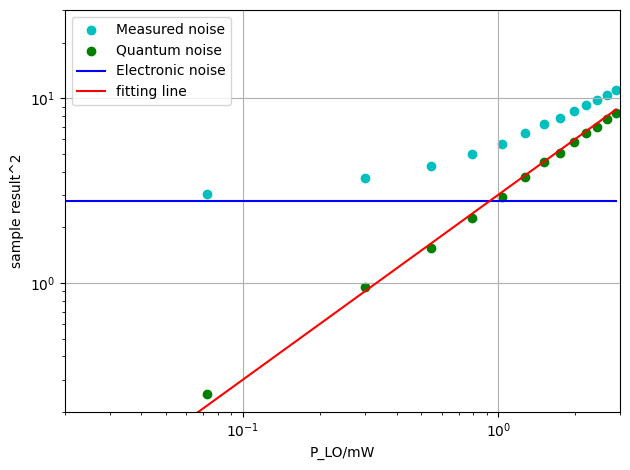

In [7]:
fig, ax = plt.subplots()
ax.scatter(P_LO, N_m_t, c='c', label='Measured noise')
ax.scatter(P_LO, N_q_t, c='g', label='Quantum noise')
ax.plot(P_LO, N_e_t, c='b', label='Electronic noise')
ax.plot(P_LO, P_LO * 3, color='r', label='fitting line')
ax.legend()
ax.grid()
ax.set_xlabel('P_LO/mW')
ax.set_ylabel('sample result^2')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(2e-2, 3)
# ax.set_ylim(N_q[1], N_m[-1]+0.00005)
ax.set_ylim(2e-1, 30)
fig.tight_layout()
plt.show()

In [8]:
'''
corelation coefficient
'''

seq = collect[-1].flatten()[:5000]
x = seq[:4900]
cc = np.empty(11)
print(cc)
for m in range(11):
    y = seq[m: m + 4900]
    xy = x * y
    cc[m] = (xy.mean() - x.mean() * y.mean()) / (x.std() * y.std())
print(cc)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[1.         0.12083338 0.08389707 0.09554304 0.03359315 0.08685493
 0.04159195 0.05729804 0.06935355 0.02186121 0.01056145]


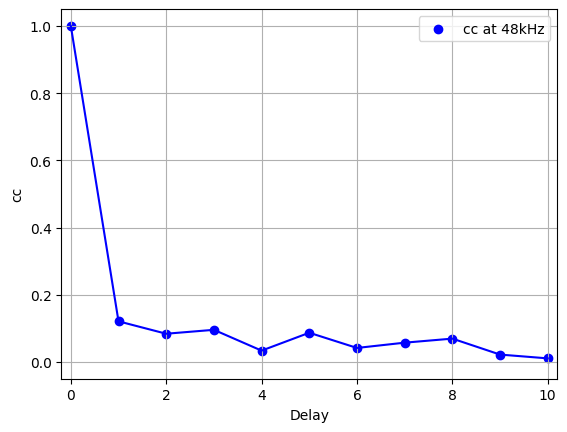

In [12]:
fig1, ax1 = plt.subplots()
ax1.scatter(np.linspace(0, 10, 11), cc, c='b', label='cc at 48kHz')
ax1.plot(np.linspace(0, 10, 11), cc, c='b')
ax1.legend()
ax1.grid()
ax1.set_xlabel('Delay')
ax1.set_ylabel('cc')
ax1.set_xlim(-0.2,10.2)
ax1.set_ylim(-0.05, 1.05)
plt.show()

In [10]:
'''
Frequency domain noise
'''
f_s = 48e3
n_s = int(2 ** 16)
presudo_sp = np.empty((17, n_s))

# electronic noise spectrum
presudo_sp[0] = abs(np.fft.fft(collect[0].flatten()[:n_s], norm='ortho'))

# measured noise spectrum
for i in range(1, 17, 1):
    presudo_sp[i] = abs(np.fft.fft(collect[i].flatten()[:n_s], norm='ortho'))
freq= np.fft.fftfreq(n=n_s, d=1/f_s)

# electronic noise power
N_e_f = np.full_like(P_LO, sum(np.power(presudo_sp[0, :int(n_s/2)], 2)) / 2)
# measured noise power
N_m_f = np.empty_like(P_LO)
for i in range(1, 17, 1):
    N_m_f[i-1] = sum(np.power(presudo_sp[i, :int(n_s/2)], 2)) / 2
# quantum noise power
N_q_f = N_m_f - N_e_f

QCNR_f = N_q_f / N_e_f
QCNR_f_dB = 10 * np.log10(QCNR_f)

print('electronic noise:', N_e_f, sep='\n', end='\n\n')
print('quantum noise:', N_q_f, sep='\n', end='\n\n')
print('QCNR:', QCNR_f, sep='\n', end='\n\n')
print('QCNR (in dB):', QCNR_f_dB, sep='\n', end='\n\n')

electronic noise:
[52011.49139404 52011.49139404 52011.49139404 52011.49139404
 52011.49139404 52011.49139404 52011.49139404 52011.49139404
 52011.49139404 52011.49139404 52011.49139404 52011.49139404
 52011.49139404 52011.49139404 52011.49139404 52011.49139404]

quantum noise:
[  1378.01000977   5409.29516602   3819.50756836   4584.48634338
  14856.18844604  23904.13269043  37684.75494385  48058.36248779
  63168.75643921  83299.4589386   86263.82647705  96252.10821533
 115480.64901733 115695.41421509 129012.06773376 136827.44221496]

QCNR:
[0.02649434 0.10400192 0.07343584 0.08814372 0.28563281 0.45959329
 0.72454671 0.92399509 1.21451538 1.60155875 1.65855322 1.85059312
 2.22029105 2.22442024 2.48045315 2.63071561]

QCNR (in dB):
[-15.76846935  -9.82958627 -11.34091932 -10.54808624  -5.44191907
  -3.37626316  -1.39933612  -0.34330338   0.8440302    2.04542873
   2.19729412   2.67310944   3.46409909   3.47216838   3.94531029
   4.20073901]



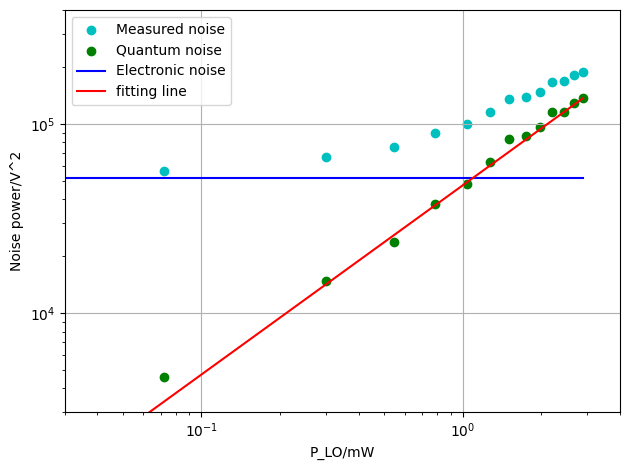

In [11]:
fig2, ax2 = plt.subplots()
ax2.scatter(P_LO, N_m_f, c='c', label='Measured noise')
ax2.scatter(P_LO, N_q_f, c='g', label='Quantum noise')
ax2.plot(P_LO, N_e_f, c='b', label='Electronic noise')
ax2.plot(P_LO, P_LO * 47344, color='r', label='fitting line')
ax2.legend()
ax2.grid()
ax2.set_xlabel('P_LO/mW')
ax2.set_ylabel('Noise power/V^2')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlim(3e-2, 4)
ax2.set_ylim(3e3, 4e5)
fig2.tight_layout()
plt.show()